In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI     
from pydantic import BaseModel, Field
import operator
load_dotenv(dotenv_path='F:\\agentic_ai\\AgenticAIWorkspace\\.env')




f:\agentic_ai\AgenticAIWorkspace\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# model = ChatOpenAI(model_name='gpt-4o mini', temperature=0.7)
model = ChatOpenAI(model_name='gpt-4o' , temperature=0.7)

In [4]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description="Detailed evaluation of the Resume")
    score:int = Field(description="Score out of 10")

In [5]:
structured_model = model.with_structured_output(EvaluationSchema)
structured_model

RunnableBinding(bound=ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000125C5B272F0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000125C729FAA0>, root_client=<openai.OpenAI object at 0x000001259D19CD40>, root_async_client=<openai.AsyncOpenAI object at 0x00000125C70A4C50>, model_name='gpt-4o', temperature=0.7, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True), kwargs={'response_format': <class '__main__.EvaluationSchema'>, 'ls_structured_output_format': {'kwargs': {'method': 'json_schema', 'strict': None}, 'schema': {'type': 'function', 'function': {'name': 'EvaluationSchema', 'description': '', 'parameters': {'properties': {'feedback': {'description': 'Detailed evaluation of the Resume', 'type': 'string'}, 'score': {'description': 'Score out of 10', 'type': 'integer'}}, 'required': ['feedback', 'score'], 'type': 'object'}}}}}, config={}, config_factories=[])
| RunnableB

In [6]:
resume = """
John Doe is a Data Scientist with 5 years of experience in building predictive models,
working with NLP, and deploying ML models using Azure and Docker. Skilled in Python,
Pandas, Scikit-learn, and TensorFlow. Worked in a retail analytics company, handling 
large datasets and collaborating with cross-functional teams.
"""

job_description = """
We are seeking a Senior Data Scientist skilled in machine learning, Python, cloud deployment
(Azure preferred), and MLOps. The candidate should have experience in end-to-end model
development, deployment, and performance monitoring.
"""

In [11]:
prompt = f""" 
Evaluate the following resume against the job description provided. Provide detailed feedback on how well the resume matches the job description
and assign a score out of 10.\n Resume: {resume} \n Job Description: {job_description}
"""
print(structured_model.invoke(prompt).feedback)
print(structured_model.invoke(prompt).score)

### Resume Evaluation:

#### Experience:
- **Years of Experience:** 
  - **Match:** John has 5 years of experience, aligning well with the senior role requirement.

#### Technical Skills:
- **Machine Learning & Python:**
  - **Match:** John is skilled in Python and has experience in building predictive models, which aligns well with the core requirements.
- **Cloud Deployment (Azure):**
  - **Match:** John has experience deploying ML models using Azure, which is specifically mentioned as a preferred skill.

#### Additional Skills:
- **MLOps:**
  - **Partial Match:** While John has experience deploying models, the resume lacks explicit mention of MLOps practices like CI/CD for ML, which could include model monitoring and versioning.

#### Experience in Model Development:
- **End-to-End Model Development:**
  - **Partial Match:** John's experience in building predictive models suggests involvement in model development, but there is no explicit mention of the entire end-to-end process.

#

In [16]:
class ResumeState(TypedDict):
    resume:str
    job_description:str
    skill_match: str
    experience_relevance: str
    communication_quality: str
    individual_score: Annotated[list[int],operator.add]
    avg_score:float
    feedback_summary:str


In [29]:
def skill_match_eval(state:ResumeState) -> ResumeState:
    prompt = f"""
    Evaluate the skill match of the following resume against the job description provided.
    Provide detailed feedback and assign a score out of 10.\n
    Resume: {state['resume']} \n Job Description: {state['job_description']}
    """
    result = structured_model.invoke(prompt)
    return {
        'skill_match': result.feedback,
        'individual_score': [result.score]
    }

In [30]:
def experience_relevance_eval(state:ResumeState) -> ResumeState:
    prompt = f"""

    Evaluate the experience relevance of the following resume against the job description provided.
    Provide detailed feedback and assign a score out of 10.\n
    Resume: {state['resume']} \n Job Description: {state['job_description']}
    """
    result = structured_model.invoke(prompt)
    return {
        'experience_relevance': result.feedback,
        'individual_score': [result.score]
    }

In [31]:
def communication_eval(state:ResumeState) -> ResumeState:
    prompt = f"""

    Evaluate the communication and tone of the following resume against the job description provided.
    Provide detailed feedback and assign a score out of 10.\n
    Resume: {state['resume']} \n Job Description: {state['job_description']}
    """
    result = structured_model.invoke(prompt)
    return {
        'communication_quality': result.feedback,
        'individual_score': [result.score]
    }

In [32]:
def feedback_summary_eval(state:ResumeState) -> ResumeState:
    avg_score = sum(state['individual_score']) / len(state['individual_score'])
    prompt = f"""
    Provide a concise summary of the feedback for the resume based on the evaluations done.
    Skill Match Feedback: {state['skill_match']}
    Experience Relevance Feedback: {state['experience_relevance']}
    Communication Quality Feedback: {state['communication_quality']}
    """
    result = model.invoke(prompt).content
    return {
        'feedback_summary': result,
        'avg_score': avg_score

    }




    

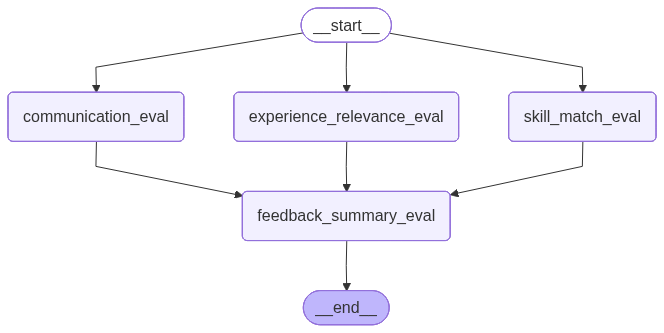

In [33]:
graph = StateGraph(ResumeState)

# add nodes
graph.add_node("skill_match_eval",skill_match_eval)
graph.add_node("experience_relevance_eval",experience_relevance_eval)
graph.add_node("communication_eval",communication_eval)

# add edges
graph.add_edge(START, "skill_match_eval")
graph.add_edge(START, "experience_relevance_eval")
graph.add_edge(START, "communication_eval")
graph.add_node("feedback_summary_eval",feedback_summary_eval)

graph.add_edge("skill_match_eval", 'feedback_summary_eval')
graph.add_edge("experience_relevance_eval", 'feedback_summary_eval')
graph.add_edge("communication_eval", 'feedback_summary_eval')
graph.add_edge('feedback_summary_eval', END)

workflow = graph.compile()
workflow

In [37]:
initial_state:ResumeState = {
    'resume': resume,   
    'job_description': job_description
}
final_state = workflow.invoke(initial_state)
print(final_state['feedback_summary'])

**Overall Summary of Resume Feedback for John Doe**

John Doe's resume demonstrates a strong alignment with the Senior Data Scientist role, particularly in terms of experience level and technical skills. He has 5 years of experience, matching the job's seniority requirement, and his proficiency in Python, machine learning, and cloud deployment using Azure is well-suited for the position. However, there are areas where the resume could be improved to enhance its appeal and better align with the job description.

**Key Strengths:**
1. **Experience Level:** John has the requisite 5 years of experience in data science, fitting the senior role's expectations.
2. **Technical Skills:** His expertise in Python, Azure, and deploying ML models is a strong match for the job requirements.
3. **Cross-Functional Collaboration:** Experience working with cross-functional teams adds value, particularly for a senior role.

**Areas for Improvement:**
1. **MLOps and Performance Monitoring:** The resume la

In [38]:
print(final_state['avg_score'])

8.0
